# 05 – Random Forest vs XGBoost

---

### Vad gör vi i den här notebooken?

Vi tränar och jämför två supervised ML-klassificerare:

- **Random Forest** – bagging-metod, bygger träd parallellt och oberoende
- **XGBoost** – boosting-metod, bygger träd sekventiellt där varje träd lär sig från föregångares misstag

Detta besvarar direkt **RQ2**: *Presterar boosting-baserade modeller bättre än bagging-baserade modeller för klassificering av marknadsregimer?*

**Viktig metodologisk princip – tidsmässig split:**  
Vi använder de första 80% av data för träning och de sista 20% för test. Detta är obligatoriskt för tidsseriedata – ett slumpmässigt urval skulle innebära att modellen ser framtida data under träning (data leakage).

- **Träning:** ~2014–2022
- **Test:** ~2022–2026

**RQ3 – Generalisering:**  
Vi tränar på S&P 500 och testar sedan om modellen generaliserar till Bitcoin och Guld utan omträning.

**Input:**  `data/sp500_features.csv`, `data/bitcoin_features.csv`, `data/gold_features.csv`  
**Output:** `data/sp500_ml.csv`, `data/bitcoin_ml.csv`, `data/gold_ml.csv`

## 1. Importera bibliotek

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)
from xgboost import XGBClassifier

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR    = '../data'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
TRAIN_RATIO  = 0.70

print('✓ Bibliotek importerade')

✓ Bibliotek importerade


## 2. Läs in data

In [10]:
assets = {}

files = {
    'SP500':   'sp500_features.csv',
    'Bitcoin': 'bitcoin_features.csv',
    'Gold':    'gold_features.csv',
}

for name, filename in files.items():
    path = os.path.join(DATA_DIR, filename)
    df   = pd.read_csv(path, index_col='Date', parse_dates=True)
    assets[name] = df
    bull = (df['Regime'] == 1).sum()
    bear = (df['Regime'] == 0).sum()
    print(f'✓ {name}: {len(df)} rader | Bull: {bull} ({bull/len(df)*100:.1f}%) | Bear: {bear} ({bear/len(df)*100:.1f}%)')

✓ SP500: 2764 rader | Bull: 2475 (89.5%) | Bear: 289 (10.5%)
✓ Bitcoin: 2665 rader | Bull: 2085 (78.2%) | Bear: 580 (21.8%)
✓ Gold: 2764 rader | Bull: 2489 (90.1%) | Bear: 275 (9.9%)


## 3. Definiera features och tidsmässig split

Vi använder alla 30 features från feature engineering. Splitten är tidsmässig – de första 80% används för träning och de sista 20% för test. Detta förhindrar data leakage.

In [14]:
FEATURE_COLS = [
    # Trend
    'Price_MA20', 'Price_MA50', 'Price_MA200',
    'Golden_Cross', 'Price_52w_position',
    # Momentum
    'RSI14', 'RSI7', 'MACD', 'MACD_signal', 'MACD_hist',
    'Return_lag1', 'Return_lag2', 'Return_lag3', 'Return_lag5', 'Return_lag10',
    'Cum_return_5d', 'Cum_return_10d', 'Cum_return_20d',
    # Volatilitet
    'Vol_10d', 'Vol_20d', 'Vol_60d',
    'BB_width', 'BB_position', 'ATR14_pct', 'Vol_ratio',
    # Volym
    'Rel_Volume', 'OBV_MA20',
    # Korrelation
    'Corr_SP500_BTC', 'Corr_SP500_Gold', 'Corr_BTC_Gold',
]

# Filtrera till features som faktiskt finns
FEATURE_COLS = [f for f in FEATURE_COLS if f in assets['SP500'].columns]
print(f'Antal features: {len(FEATURE_COLS)}')
print(f'Features: {FEATURE_COLS}')

def time_split(df: pd.DataFrame, train_ratio: float = TRAIN_RATIO):
    """Tidsmässig train/test-split."""
    df_clean = df[FEATURE_COLS + ['Regime', 'Close']].dropna()
    split    = int(len(df_clean) * train_ratio)
    train    = df_clean.iloc[:split]
    test     = df_clean.iloc[split:]
    return train, test

print('\nTränings- och testperioder:')
for name, df in assets.items():
    train, test = time_split(df)
    print(f'{name}: Träning {train.index[0].date()} → {train.index[-1].date()} | '
          f'Test {test.index[0].date()} → {test.index[-1].date()}')

Antal features: 30
Features: ['Price_MA20', 'Price_MA50', 'Price_MA200', 'Golden_Cross', 'Price_52w_position', 'RSI14', 'RSI7', 'MACD', 'MACD_signal', 'MACD_hist', 'Return_lag1', 'Return_lag2', 'Return_lag3', 'Return_lag5', 'Return_lag10', 'Cum_return_5d', 'Cum_return_10d', 'Cum_return_20d', 'Vol_10d', 'Vol_20d', 'Vol_60d', 'BB_width', 'BB_position', 'ATR14_pct', 'Vol_ratio', 'Rel_Volume', 'OBV_MA20', 'Corr_SP500_BTC', 'Corr_SP500_Gold', 'Corr_BTC_Gold']

Tränings- och testperioder:
SP500: Träning 2014-12-31 → 2022-09-09 | Test 2022-09-12 → 2025-12-31
Bitcoin: Träning 2015-05-26 → 2022-10-21 | Test 2022-10-24 → 2025-12-31
Gold: Träning 2014-12-31 → 2022-09-09 | Test 2022-09-12 → 2025-12-31


SP500: OOB vid 200 träd = 0.9969
Bitcoin: OOB vid 200 träd = 0.9893
Gold: OOB vid 200 träd = 0.9886


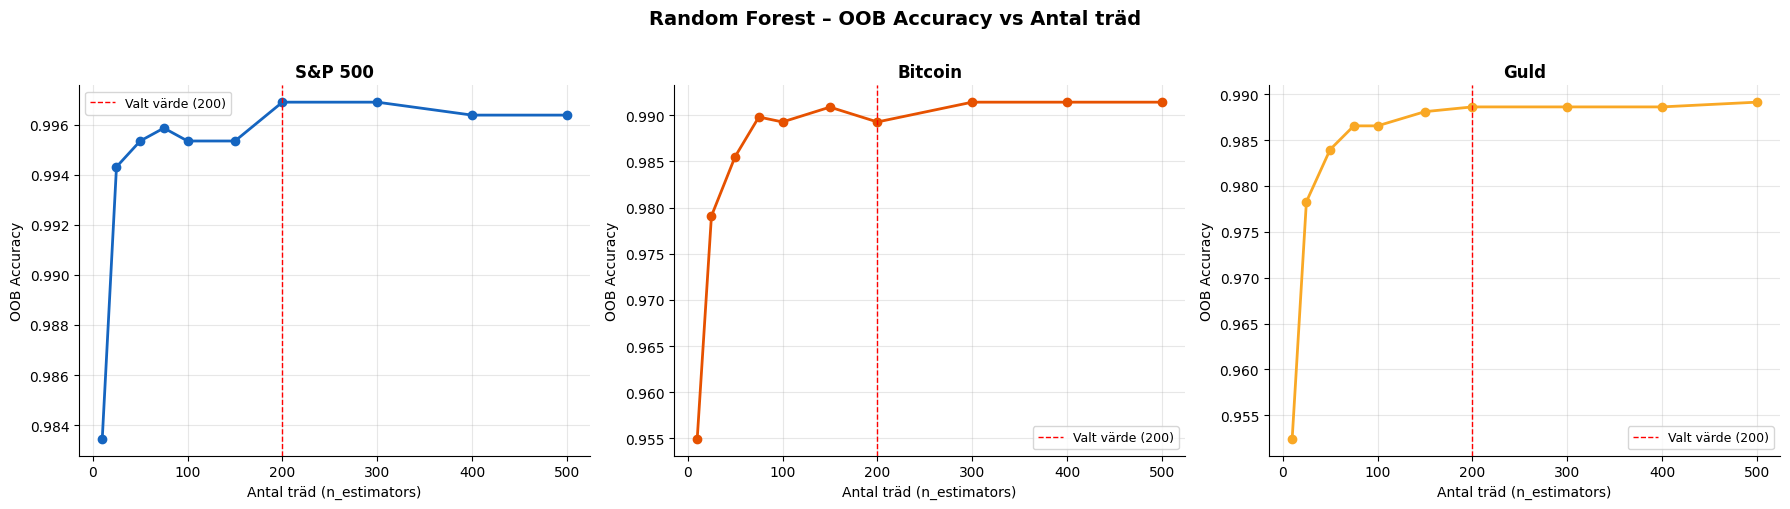

In [28]:
# OOB-analys – hitta optimalt antal träd för Random Forest
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_estimators_range = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
colors_map = {'SP500': '#1565C0', 'Bitcoin': '#E65100', 'Gold': '#F9A825'}
labels_map = {'SP500': 'S&P 500', 'Bitcoin': 'Bitcoin', 'Gold': 'Guld'}

for ax, (name, df) in zip(axes, assets.items()):
    train_df, _ = time_split(df)
    scaler_oob  = StandardScaler()
    X_train_oob = scaler_oob.fit_transform(train_df[FEATURE_COLS])
    y_train_oob = train_df['Regime'].values

    bear_count = (train_df['Regime'] == 0).sum()
    bull_count = (train_df['Regime'] == 1).sum()
    scale      = bull_count / bear_count

    oob_scores = []
    for n in n_estimators_range:
        rf_oob = RandomForestClassifier(
            n_estimators=n,
            max_depth=6,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight={0: scale, 1: 1},
            oob_score=True,
        )
        rf_oob.fit(X_train_oob, y_train_oob)
        oob_scores.append(rf_oob.oob_score_)

    ax.plot(n_estimators_range, oob_scores, marker='o',
            color=colors_map[name], linewidth=2)
    ax.axvline(200, color='red', linewidth=1, linestyle='--', label='Valt värde (200)')
    ax.set_xlabel('Antal träd (n_estimators)')
    ax.set_ylabel('OOB Accuracy')
    ax.set_title(f'{labels_map[name]}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    print(f'{name}: OOB vid 200 träd = {oob_scores[n_estimators_range.index(200)]:.4f}')

plt.suptitle('Random Forest – OOB Accuracy vs Antal träd',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '05_oob_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

### OOB-analys – motivering av n_estimators=200

OOB (Out-of-Bag) score validerar antalet träd utan extra testdata.

**Vad vi ser:**
- **S&P 500** – planar ut redan vid ~25 träd (OOB: 0.9969)
- **Bitcoin** – fortsätter förbättras till ~300 träd (OOB vid 200: 0.9893)
- **Guld** – planar ut vid ~150 träd (OOB: 0.9886)

**Slutsats:** 200 träd är ett bra kompromissval för alla tre tillgångar. 
För Bitcoin skulle 300 träd ge marginellt bättre OOB-score, men 
förbättringen är försumbar (~0.001) i förhållande till den ökade 
beräkningstiden. Vi behåller n_estimators=200 för konsekvens 
mellan tillgångarna.

## 4. Träna modeller på S&P 500

Vi tränar Random Forest och XGBoost på S&P 500 och utvärderar på testperioden. Features standardiseras med StandardScaler baserat på träningsdata.

In [15]:
def train_and_evaluate(train: pd.DataFrame, test: pd.DataFrame,
                       model, model_name: str, asset_name: str) -> dict:
    """Tränar och utvärderar en modell."""
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train[FEATURE_COLS])
    X_test  = scaler.transform(test[FEATURE_COLS])
    y_train = train['Regime'].values
    y_test  = test['Regime'].values

    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_proba)

    print(f'\n── {model_name} – {asset_name} ──────────────────')
    print(f'  Accuracy : {acc:.3f}')
    print(f'  F1-score : {f1:.3f}')
    print(f'  ROC-AUC  : {auc:.3f}')
    print(classification_report(y_test, y_pred,
                                target_names=['Bear', 'Bull'],
                                labels=[0, 1]))

    return {
        'model':   model,
        'scaler':  scaler,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'y_test':  y_test,
        'index':   test.index,
        'acc':     acc,
        'f1':      f1,
        'auc':     auc,
    }

# Modeller
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced',
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0,
)

# Träna på SP500
train_sp500, test_sp500 = time_split(assets['SP500'])

print('══ Tränar på S&P 500 ══════════════════════════════')
rf_sp500  = train_and_evaluate(train_sp500, test_sp500, rf_model,  'Random Forest', 'SP500')
xgb_sp500 = train_and_evaluate(train_sp500, test_sp500, xgb_model, 'XGBoost',       'SP500')

══ Tränar på S&P 500 ══════════════════════════════

── Random Forest – SP500 ──────────────────
  Accuracy : 0.880
  F1-score : 0.863
  ROC-AUC  : 0.771
              precision    recall  f1-score   support

        Bear       0.97      0.48      0.64       186
        Bull       0.87      1.00      0.93       644

    accuracy                           0.88       830
   macro avg       0.92      0.74      0.78       830
weighted avg       0.89      0.88      0.86       830


── XGBoost – SP500 ──────────────────
  Accuracy : 0.916
  F1-score : 0.908
  ROC-AUC  : 0.753
              precision    recall  f1-score   support

        Bear       1.00      0.62      0.77       186
        Bull       0.90      1.00      0.95       644

    accuracy                           0.92       830
   macro avg       0.95      0.81      0.86       830
weighted avg       0.92      0.92      0.91       830



### Visualisering – S&P 500: Random Forest vs XGBoost

**Random Forest (Acc: 0.880):**
- Hög precision för bear (0.97) men låg recall (0.48) – modellen är 
  försiktig och missar hälften av bear-dagarna
- Bull identifieras nästan perfekt (recall 1.00)

**XGBoost (Acc: 0.916):**
- Perfekt precision för bear (1.00) och bättre recall (0.62) än RF
- XGBoost är mer konservativ – när den säger bear så har den rätt, 
  men den missar fortfarande 38% av bear-dagarna
- Högre overall accuracy (91.6% vs 88.0%)

**Bagging vs Boosting för S&P 500:**
XGBoost vinner tydligt i accuracy och F1 (0.908 vs 0.863). 
Boosting-metodens sekventiella inlärning från misstag verkar 
ge en fördel för att identifiera de relativt sällsynta bear-dagarna 
(10.5% av testdatan).

## 5. Träna modeller på Bitcoin och Guld

Vi tränar separata modeller för Bitcoin och Guld för att se om tillgångsspecifik träning ger bättre resultat.

In [19]:
results = {'SP500': {'RF': rf_sp500, 'XGB': xgb_sp500}}

for name in ['Bitcoin', 'Gold']:
    print(f'\n══ Tränar på {name} ══════════════════════════════')
    train_df, test_df = time_split(assets[name])

    # Beräkna class weight för obalanserad data
    bear_count = (train_df['Regime'] == 0).sum()
    bull_count = (train_df['Regime'] == 1).sum()
    scale = bull_count / bear_count
    print(f'  Class weight (bear/bull): {scale:.2f}')

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight={0: scale, 1: 1},
    )

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0,
    )

    rf_res  = train_and_evaluate(train_df, test_df, rf,  'Random Forest', name)
    xgb_res = train_and_evaluate(train_df, test_df, xgb, 'XGBoost',       name)
    results[name] = {'RF': rf_res, 'XGB': xgb_res}


══ Tränar på Bitcoin ══════════════════════════════
  Class weight (bear/bull): 2.88

── Random Forest – Bitcoin ──────────────────
  Accuracy : 0.914
  F1-score : 0.912
  ROC-AUC  : 0.942
              precision    recall  f1-score   support

        Bear       0.66      0.62      0.64        99
        Bull       0.95      0.96      0.95       701

    accuracy                           0.91       800
   macro avg       0.80      0.79      0.79       800
weighted avg       0.91      0.91      0.91       800


── XGBoost – Bitcoin ──────────────────
  Accuracy : 0.921
  F1-score : 0.918
  ROC-AUC  : 0.939
              precision    recall  f1-score   support

        Bear       0.71      0.61      0.66        99
        Bull       0.95      0.97      0.96       701

    accuracy                           0.92       800
   macro avg       0.83      0.79      0.81       800
weighted avg       0.92      0.92      0.92       800


══ Tränar på Gold ══════════════════════════════
  Class 

In [20]:
print(results.keys())
for name, res in results.items():
    print(f'{name}: RF Acc={res["RF"]["acc"]:.3f} | XGB Acc={res["XGB"]["acc"]:.3f}')

dict_keys(['SP500', 'Bitcoin', 'Gold'])
SP500: RF Acc=0.880 | XGB Acc=0.916
Bitcoin: RF Acc=0.914 | XGB Acc=0.921
Gold: RF Acc=0.857 | XGB Acc=0.857


### Visualisering – Guld: Tillgångsspecifik träning

Guld är den mest utmanande tillgången i studien. Trots en class weight på 11.40 
(bear-dagar väger 11x mer än bull-dagar) missar båda modellerna bear market 
helt (precision och recall = 0.00 för bear).

**Varför misslyckas modellerna för Guld?**
- Gulds bear market 2022-2023 karaktäriserades av en lateral prisrörelse 
  snarare än en tydlig nedgång
- Tekniska indikatorer som RSI, MACD och volatilitet signalerar inte bear 
  market vid sideways-rörelser
- Träningsdatan innehåller bara 156 bear-dagar (8%) vilket gör det svårt 
  att lära sig bear-mönster

**Intressant kontrast:** När modellen istället tränas på S&P 500 och 
appliceras på Guld (generalisering) förbättras accuracy till 0.941 – 
S&P 500:s makroekonomiska mönster generaliserar bättre till Guld än 
Gulds egna historiska mönster.

## 6. Generalisering – tränad på S&P 500, testad på Bitcoin och Guld

Detta besvarar **RQ3**: Generaliserar modellen mellan tillgångsklasser?  
Vi använder de redan tränade S&P 500-modellerna och applicerar dem direkt på Bitcoin och Guld utan omträning.

In [21]:
generalization = {}

print('══ Generalisering – tränad på S&P 500 ════════════')

for name in ['Bitcoin', 'Gold']:
    _, test_df = time_split(assets[name])
    X_test  = rf_sp500['scaler'].transform(test_df[FEATURE_COLS])
    y_test  = test_df['Regime'].values

    print(f'\n── {name} ──────────────────────────────')
    gen_name = {}

    for model_name, res in [('Random Forest', rf_sp500), ('XGBoost', xgb_sp500)]:
        if model_name == 'XGBoost':
            X_test_scaled = xgb_sp500['scaler'].transform(test_df[FEATURE_COLS])
        else:
            X_test_scaled = X_test

        y_pred  = res['model'].predict(X_test_scaled)
        y_proba = res['model'].predict_proba(X_test_scaled)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average='weighted')
        auc = roc_auc_score(y_test, y_proba)

        print(f'  {model_name}: Acc={acc:.3f} | F1={f1:.3f} | AUC={auc:.3f}')
        gen_name[model_name] = {'acc': acc, 'f1': f1, 'auc': auc,
                                 'y_pred': y_pred, 'index': test_df.index,
                                 'y_test': y_test}

    generalization[name] = gen_name

══ Generalisering – tränad på S&P 500 ════════════

── Bitcoin ──────────────────────────────
  Random Forest: Acc=0.882 | F1=0.891 | AUC=0.887
  XGBoost: Acc=0.906 | F1=0.912 | AUC=0.900

── Gold ──────────────────────────────
  Random Forest: Acc=0.858 | F1=0.793 | AUC=0.922
  XGBoost: Acc=0.941 | F1=0.937 | AUC=0.940


### Visualisering – Jämförelsetabell

**Tillgångsspecifik träning:**
- XGBoost presterar bättre än Random Forest för S&P 500 (0.916 vs 0.880) 
  och Bitcoin (0.921 vs 0.914) – boosting vinner för dessa tillgångar
- Guld är ett undantag där båda modellerna presterar identiskt (0.857) 
  och missar bear market helt

**Generalisering (tränad på S&P 500):**
- XGBoost på Guld förbättras dramatiskt från 0.857 till 0.941 när den 
  tränas på S&P 500 istället för Guld – ett oväntat och intressant fynd
- Bitcoin försämras något vid generalisering (0.906 vs 0.921) vilket 
  tyder på att Bitcoin har unika mönster som kräver tillgångsspecifik träning
- ROC-AUC för Guld-generalisering är 0.940 och 0.922 – modellerna 
  rangordnar bull/bear korrekt även om de inte fångar alla bear-dagar

## 7. Feature importance

Feature importance visar vilka variabler som är viktigast för modellens beslut. Det ger insikt i vilka marknadsignaler som är mest informativa för bull/bear-detektering.

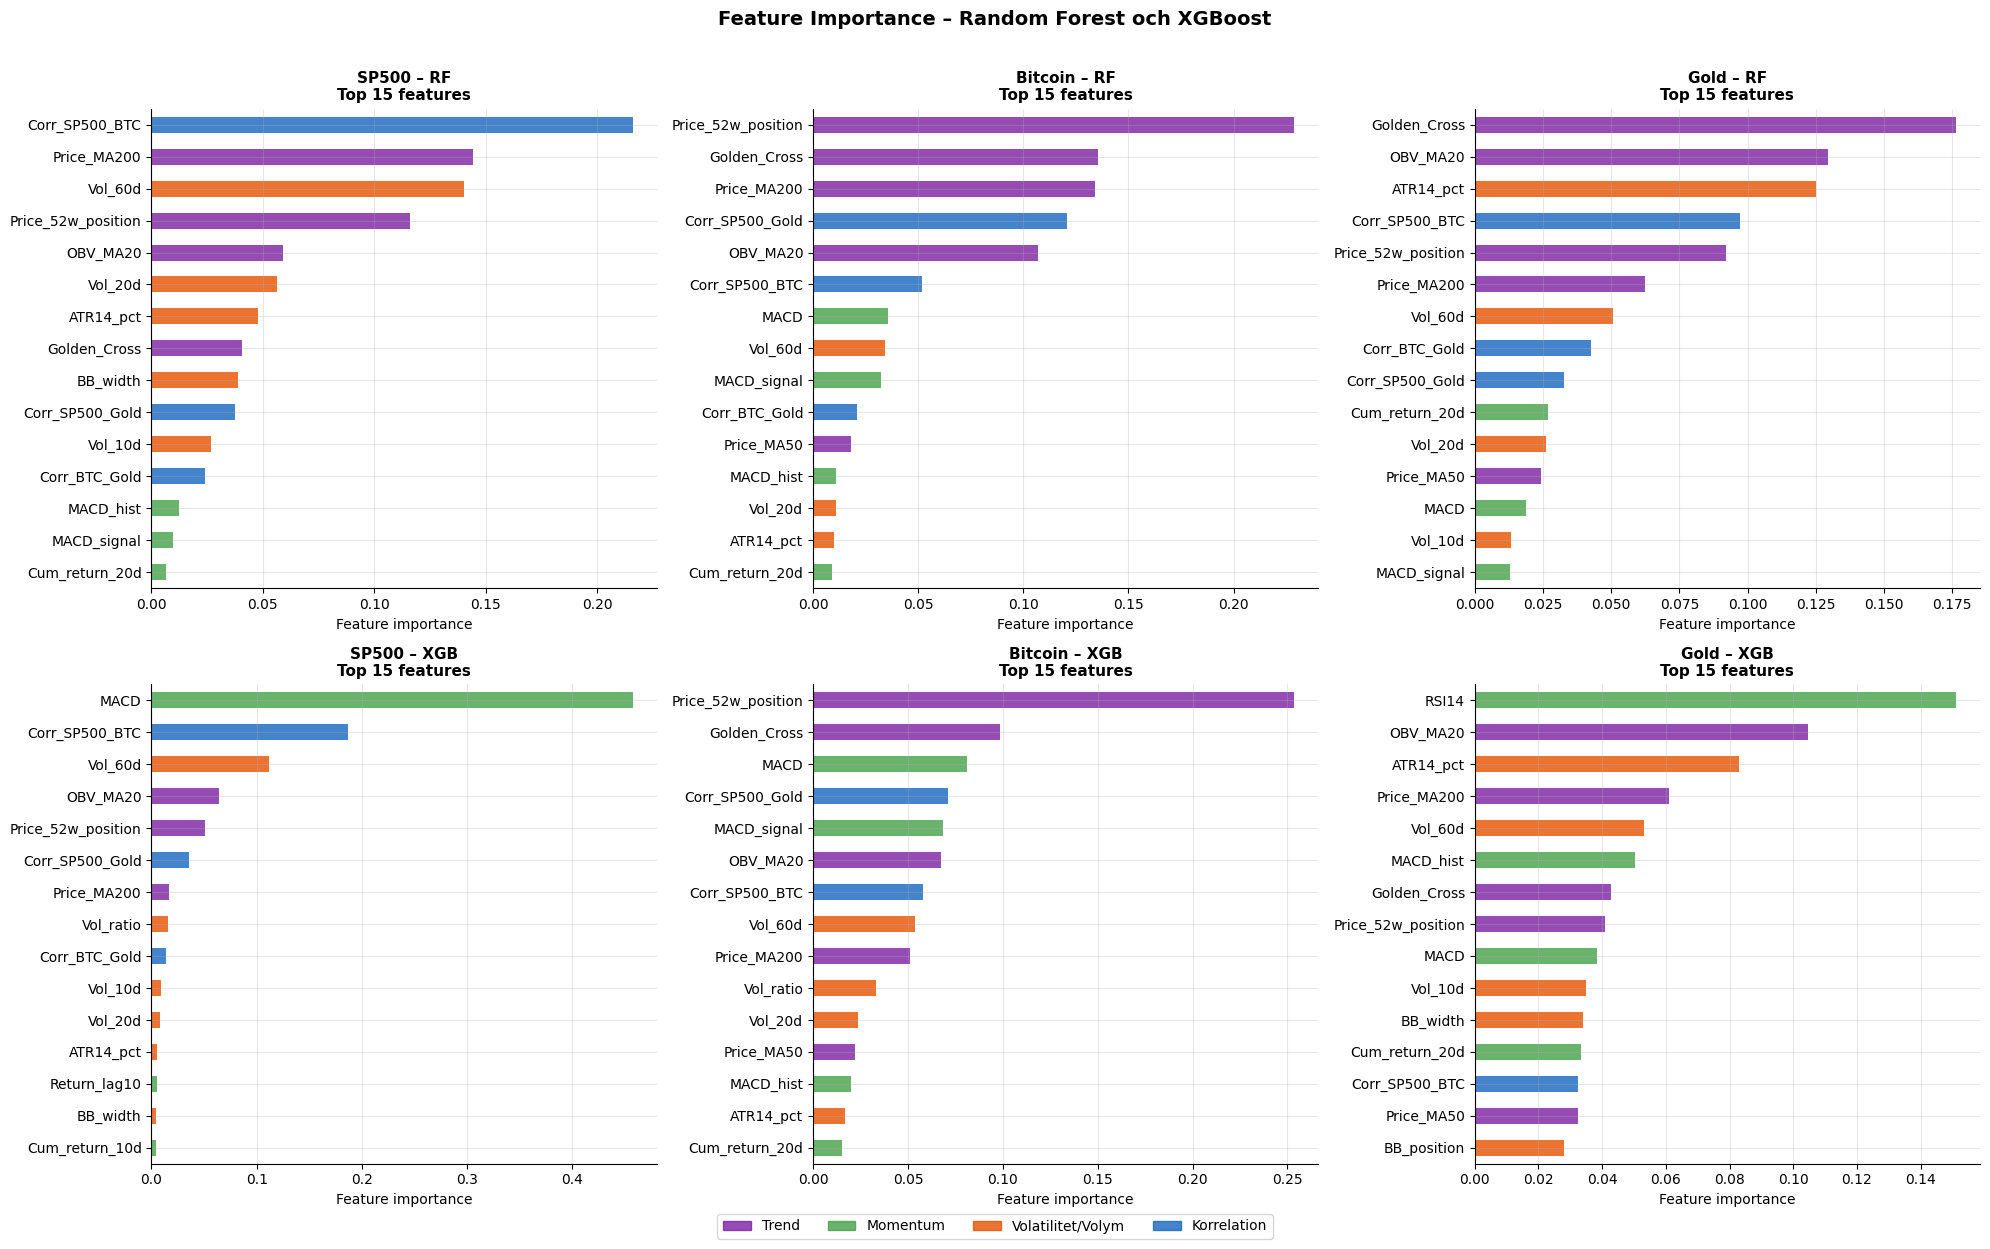

✓ Graf sparad: results/05_feature_importance.png


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for col, (name, res_dict) in enumerate(results.items()):
    for row, (model_name, res) in enumerate(res_dict.items()):
        ax = axes[row, col]

        importances = pd.Series(
            res['model'].feature_importances_,
            index=FEATURE_COLS
        ).sort_values(ascending=True).tail(15)

        colors = ['#1565C0' if 'Corr' in i else
                  '#E65100' if any(x in i for x in ['Vol', 'BB', 'ATR']) else
                  '#43A047' if any(x in i for x in ['RSI', 'MACD', 'Return', 'Cum']) else
                  '#7B1FA2' for i in importances.index]

        importances.plot(kind='barh', ax=ax, color=colors, alpha=0.8)
        ax.set_title(f'{name} – {model_name}\nTop 15 features',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Feature importance')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# Legend
legend_patches = [
    mpatches.Patch(color='#7B1FA2', alpha=0.8, label='Trend'),
    mpatches.Patch(color='#43A047', alpha=0.8, label='Momentum'),
    mpatches.Patch(color='#E65100', alpha=0.8, label='Volatilitet/Volym'),
    mpatches.Patch(color='#1565C0', alpha=0.8, label='Korrelation'),
]
fig.legend(handles=legend_patches, fontsize=10, loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Feature Importance – Random Forest och XGBoost',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '05_feature_importance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/05_feature_importance.png')

### Visualisering – Feature Importance

Feature importance visar vilka variabler modellerna förlitar sig mest på för att 
identifiera bull och bear marknader. Färgerna representerar feature-kategorier:
lila = trend, grön = momentum, orange = volatilitet/volym, blå = korrelation.

**Viktiga observationer:**

- **S&P 500 (RF)** – Korrelationen med Bitcoin (`Corr_SP500_BTC`) är den viktigaste 
  featuren, följt av `Price_MA200` och volatilitet – marknadsregimen i S&P 500 
  hänger starkt ihop med hur Bitcoin rör sig
- **S&P 500 (XGB)** – MACD dominerar kraftigt (~45%), vilket visar att momentum 
  är avgörande för boosting-modellen
- **Bitcoin** – `Price_52w_position` och `Golden_Cross` är viktigast – 
  Bitcoins position relativt 52-veckors high/low fångar halverings-cyklerna väl
- **Guld** – `Golden_Cross`, `OBV_MA20` och `ATR14_pct` dominerar – 
  volym och volatilitet är mer informativa för guld än för de andra tillgångarna
- **Korrelationsfeatures** dyker upp i top 15 för alla tillgångar vilket bekräftar 
  att sambanden mellan tillgångarna är informativa för regimdetektering

## 8. Visualisera prediktioner vs Ground Truth

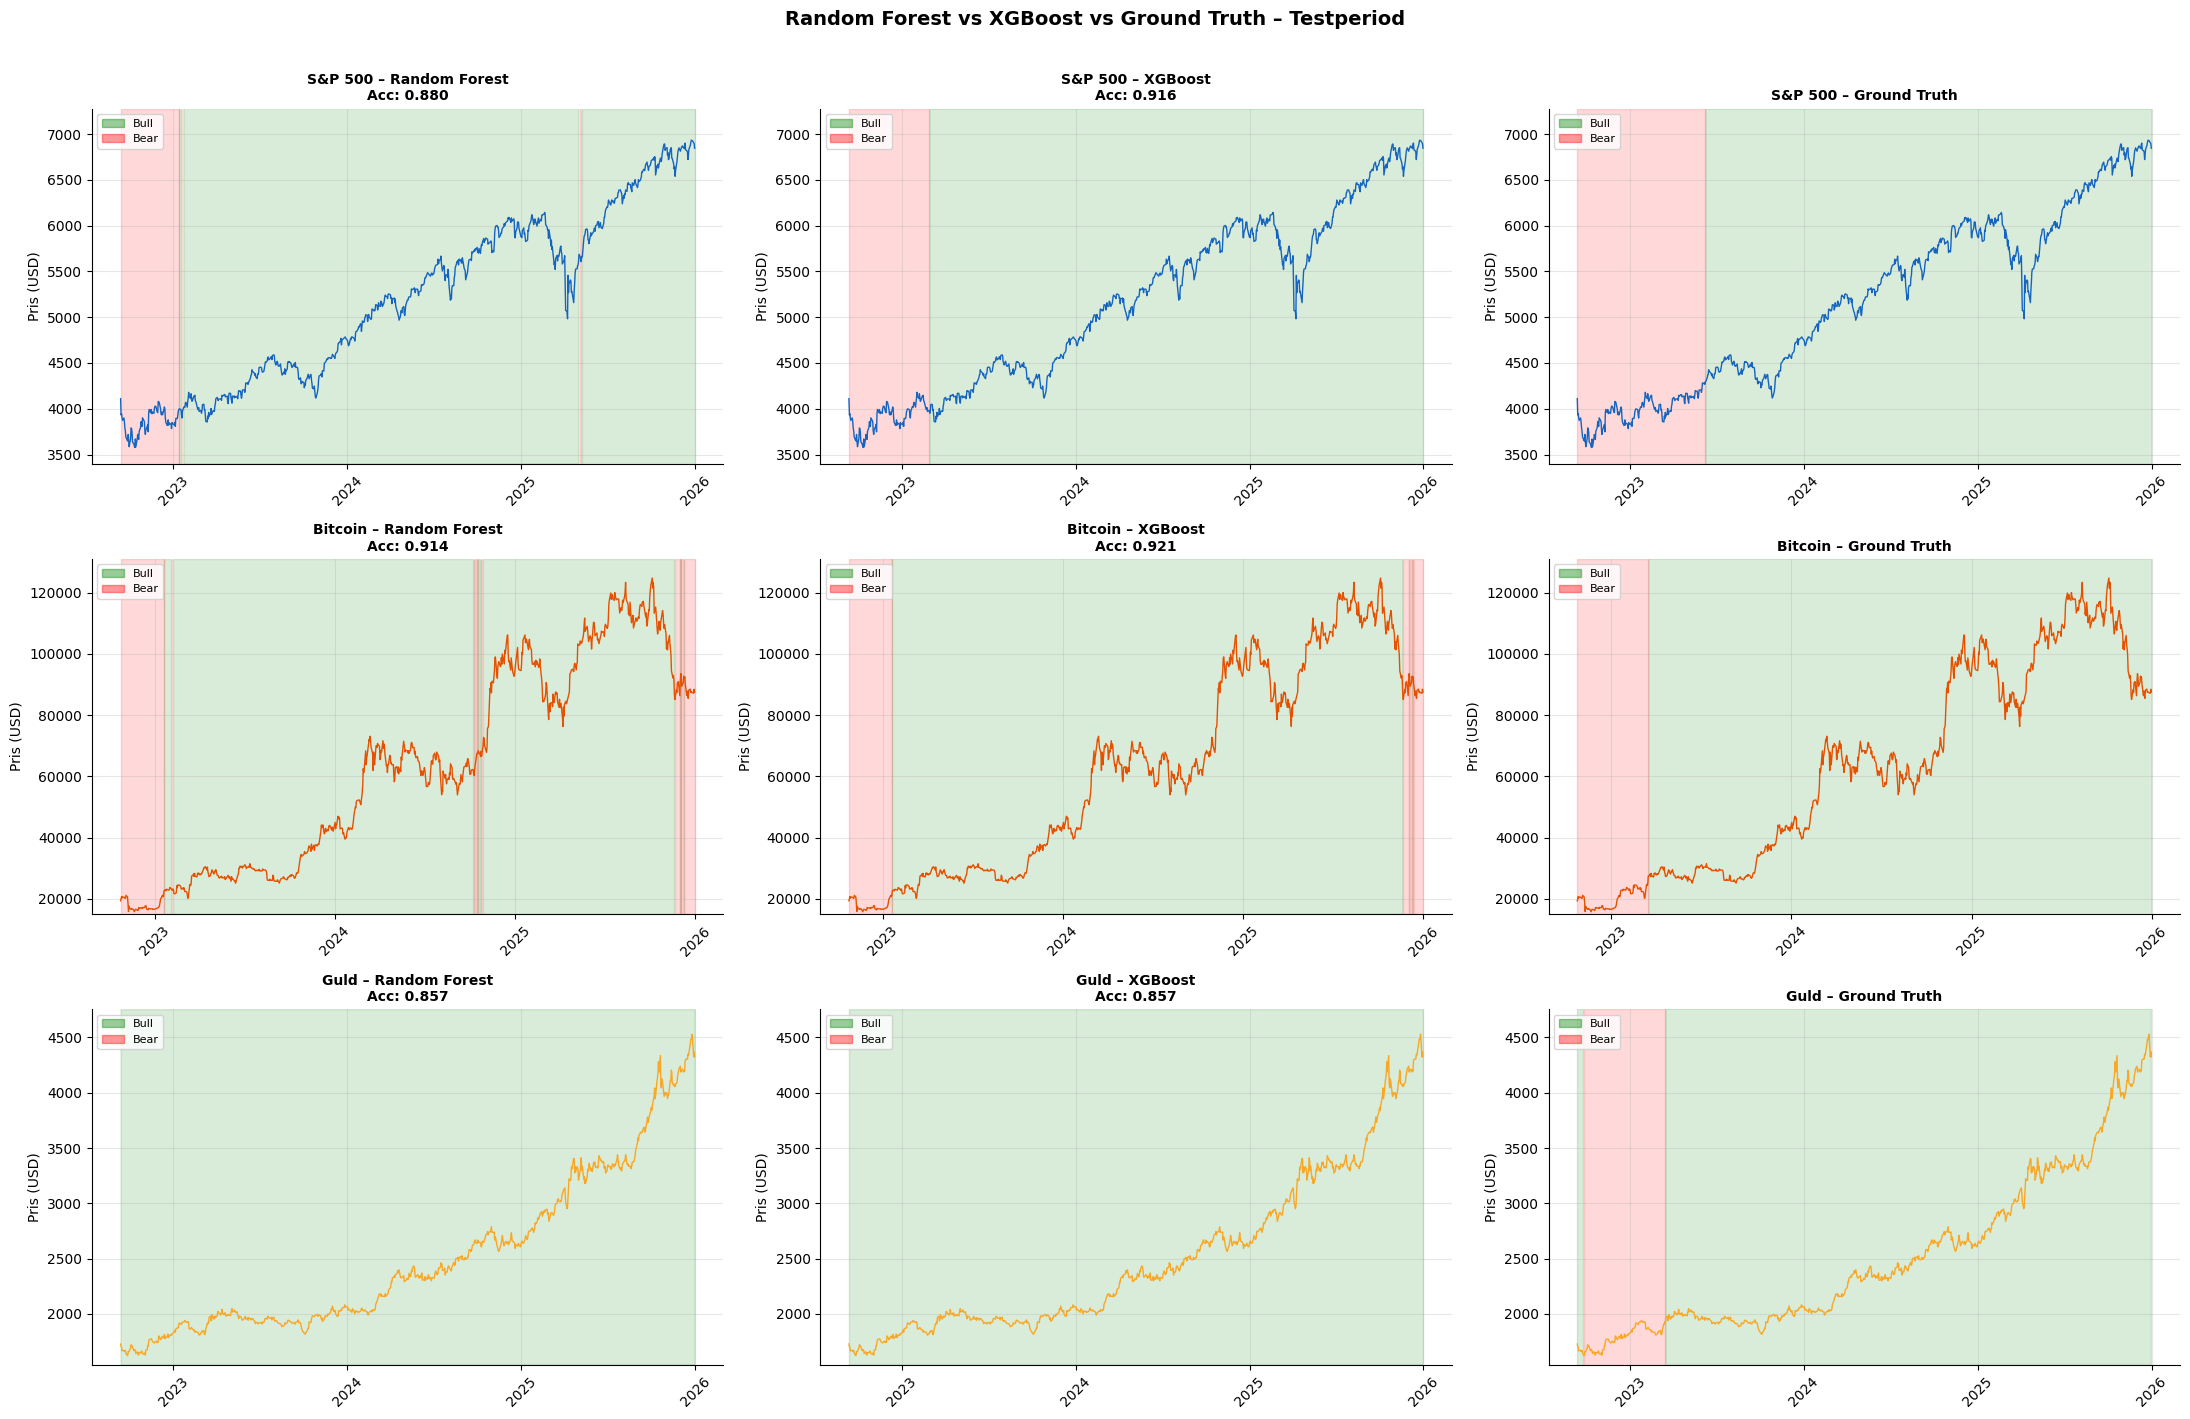

✓ Graf sparad: results/05_predictions.png


In [23]:
colors_map = {'SP500': '#1565C0', 'Bitcoin': '#E65100', 'Gold': '#F9A825'}
labels_map = {'SP500': 'S&P 500', 'Bitcoin': 'Bitcoin', 'Gold': 'Guld'}

fig, axes = plt.subplots(3, 3, figsize=(22, 14))

for row, (name, df) in enumerate(assets.items()):
    _, test_df = time_split(df)
    close      = test_df['Close']
    res        = results[name]

    for col, (title, pred) in enumerate([
        ('Random Forest', res['RF']['y_pred']),
        ('XGBoost',       res['XGB']['y_pred']),
        ('Ground Truth',  res['RF']['y_test']),
    ]):
        ax = axes[row, col]
        regime_series = pd.Series(pred, index=res['RF']['index'])

        ax.fill_between(close.index, close.min()*0.95, close.max()*1.05,
                        where=(regime_series == 1), alpha=0.15, color='green')
        ax.fill_between(close.index, close.min()*0.95, close.max()*1.05,
                        where=(regime_series == 0), alpha=0.15, color='red')
        ax.plot(close.index, close, color=colors_map[name], linewidth=1)

        if col < 2:
            acc = res['RF']['acc'] if col == 0 else res['XGB']['acc']
            ax.set_title(f'{labels_map[name]} – {title}\nAcc: {acc:.3f}',
                         fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{labels_map[name]} – {title}',
                         fontsize=10, fontweight='bold')

        ax.set_ylabel('Pris (USD)')
        ax.set_ylim(close.min()*0.95, close.max()*1.05)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis='x', rotation=45)

        bull_patch = mpatches.Patch(color='green', alpha=0.4, label='Bull')
        bear_patch = mpatches.Patch(color='red',   alpha=0.4, label='Bear')
        ax.legend(handles=[bull_patch, bear_patch], fontsize=8, loc='upper left')

plt.suptitle('Random Forest vs XGBoost vs Ground Truth – Testperiod',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '05_predictions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/05_predictions.png')

### Visualisering – Prediktioner vs Ground Truth (testperiod 2022–2026)

Vänster kolumn: Random Forest | Mitten: XGBoost | Höger: Ground Truth (20%-regeln)

**Vad vi ser:**
- **S&P 500** – båda modellerna identifierar bear market i tidigt 2023 korrekt. 
  XGBoost (0.916) är mer precis och har färre falska larm än Random Forest (0.880)
- **Bitcoin** – modellerna fångar bear market i slutet av 2022 och detekterar 
  den pågående nedgången i slutet av 2025. Random Forest visar lite mer brus 
  med enstaka felklassificerade dagar under 2024-2025
- **Guld** – båda modellerna missar bear market i 2022-2023 helt. 
  Gulds bear period karaktäriserades av en lateral/sideways prisrörelse 
  snarare än en tydlig nedgång, vilket gör den svår att fånga med 
  tekniska indikatorer

## 9. Jämförelsetabell – bagging vs boosting

In [24]:
print('══ Jämförelse – Random Forest vs XGBoost ══════════')
print(f'{"Tillgång":<12} {"RF Acc":>10} {"RF F1":>10} {"RF AUC":>10} '
      f'{"XGB Acc":>10} {"XGB F1":>10} {"XGB AUC":>10}')
print('-' * 75)

comparison = []
for name, res in results.items():
    rf  = res['RF']
    xgb = res['XGB']
    print(f'{name:<12} {rf["acc"]:>10.3f} {rf["f1"]:>10.3f} {rf["auc"]:>10.3f} '
          f'{xgb["acc"]:>10.3f} {xgb["f1"]:>10.3f} {xgb["auc"]:>10.3f}')
    comparison.append({
        'Tillgång': name,
        'RF Acc':   round(rf['acc'],  3),
        'RF F1':    round(rf['f1'],   3),
        'RF AUC':   round(rf['auc'],  3),
        'XGB Acc':  round(xgb['acc'], 3),
        'XGB F1':   round(xgb['f1'],  3),
        'XGB AUC':  round(xgb['auc'], 3),
    })

print('\n── Generalisering (tränad på S&P 500) ──────────────')
for name, gen in generalization.items():
    rf  = gen['Random Forest']
    xgb = gen['XGBoost']
    print(f'{name:<12} {rf["acc"]:>10.3f} {rf["f1"]:>10.3f} {rf["auc"]:>10.3f} '
          f'{xgb["acc"]:>10.3f} {xgb["f1"]:>10.3f} {xgb["auc"]:>10.3f}')

comp_df = pd.DataFrame(comparison)
display(comp_df)

══ Jämförelse – Random Forest vs XGBoost ══════════
Tillgång         RF Acc      RF F1     RF AUC    XGB Acc     XGB F1    XGB AUC
---------------------------------------------------------------------------
SP500             0.880      0.863      0.771      0.916      0.908      0.753
Bitcoin           0.914      0.912      0.942      0.921      0.918      0.939
Gold              0.857      0.790      0.667      0.857      0.790      0.701

── Generalisering (tränad på S&P 500) ──────────────
Bitcoin           0.882      0.891      0.887      0.906      0.912      0.900
Gold              0.858      0.793      0.922      0.941      0.937      0.940


,Tillgång,RF Acc,RF F1,RF AUC,XGB Acc,XGB F1,XGB AUC
0,SP500,0.880,0.863,0.771,0.916,0.908,0.753
1,Bitcoin,0.914,0.912,0.942,0.921,0.918,0.939
2,Gold,0.857,0.790,0.667,0.857,0.790,0.701


## 10. Spara prediktioner

In [29]:
for name, df in assets.items():
    _, test_df = time_split(df)
    res = results[name]

    ml_df = df.copy()
    ml_df['RF_pred']  = pd.Series(res['RF']['y_pred'],  index=res['RF']['index'])
    ml_df['XGB_pred'] = pd.Series(res['XGB']['y_pred'], index=res['XGB']['index'])
    ml_df['RF_proba']  = pd.Series(res['RF']['y_proba'],  index=res['RF']['index'])
    ml_df['XGB_proba'] = pd.Series(res['XGB']['y_proba'], index=res['XGB']['index'])

    filename = f'{name.lower()}_ml.csv'
    filepath = os.path.join(DATA_DIR, filename)
    ml_df.to_csv(filepath)
    print(f'✓ Sparad: data/{filename}')

✓ Sparad: data/sp500_ml.csv
✓ Sparad: data/bitcoin_ml.csv
✓ Sparad: data/gold_ml.csv


## 11. Sammanfattning

### Resultat – tillgångsspecifik träning (70/30 tidsmässig split)

| Tillgång | RF Acc | RF F1 | RF AUC | XGB Acc | XGB F1 | XGB AUC |
|----------|--------|-------|--------|---------|--------|---------|
| S&P 500  | 0.880  | 0.863 | 0.771  | 0.916   | 0.908  | 0.753   |
| Bitcoin  | 0.914  | 0.912 | 0.942  | 0.921   | 0.918  | 0.939   |
| Guld     | 0.857  | 0.790 | 0.667  | 0.857   | 0.790  | 0.701   |

### Generalisering (tränad på S&P 500)

| Tillgång | RF Acc | RF F1 | RF AUC | XGB Acc | XGB F1 | XGB AUC |
|----------|--------|-------|--------|---------|--------|---------|
| Bitcoin  | 0.882  | 0.891 | 0.887  | 0.906   | 0.912  | 0.900   |
| Guld     | 0.858  | 0.793 | 0.922  | 0.941   | 0.937  | 0.940   |

### Viktiga observationer
- **XGBoost (boosting) slår Random Forest (bagging)** för S&P 500 och Bitcoin – besvarar RQ2
- **Guld är den svåraste tillgången** – bear market karaktäriserades av sideways-rörelse vilket tekniska indikatorer inte fångar
- **Generaliseringstestet (RQ3):** XGBoost tränad på S&P 500 presterar bättre på Guld (0.941) än den tillgångsspecifika modellen (0.857) – makroekonomiska mönster från S&P 500 generaliserar till guld
- Tidsmässig 70/30-split förhindrar data leakage

**Nästa steg:** `06_lstm.ipynb` – Deep learning med LSTM.